# Datahåndtering IV: Kalibrering og sammenlikning av resultater

```{admonition} Læringsutbytte
Etter å ha arbeidet med dette temaet, skal du kunne:

1. bruke lineær regresjon til å lage en kalibreringsmodell
2. tolke stigningstall, konstantledd og $R^2$ i en kjemisk sammenheng
3. bruke modellen til å bestemme en ukjent konsentrasjon
4. forklare hva en nullhypotese og en p-verdi betyr
5. velge mellom ettutvalgs t-test og paret t-test i enkle kjemiske situasjoner
6. vurdere én mistenkelig måling på en dokumentert måte
```

I forrige kapittel brukte vi statistikk til å beskrive måleserier og usikkerheten i et gjennomsnitt. Nå skal vi bruke de samme ideene til to vanlige oppgaver i kjemi:

1. Vi lager en kalibreringsmodell og bruker den til å bestemme en ukjent konsentrasjon.
2. Vi sammenlikner et måleresultat med en referanseverdi eller med en annen analysemetode.

Målet er ikke å samle flest mulig statistiske tester. Målet er å velge en metode som svarer på det kjemiske spørsmålet vårt.

## Del 1: Fra kalibreringsstandarder til ukjent konsentrasjon

### Den kjemiske modellen

I UV–Vis-spektroskopi beskriver Beer–Lamberts lov sammenhengen mellom absorbans og konsentrasjon:

$$
A=\varepsilon lc
$$

Her er $A$ absorbansen, $\varepsilon$ den molare absorptiviteten, $l$ lysveien og $c$ konsentrasjonen. Når lysveien og de kjemiske betingelsene er konstante, forventer vi at absorbansen øker lineært med konsentrasjonen.

Virkelige målinger ligger ikke på en helt perfekt linje. Derfor tilpasser vi en rett linje til kalibreringsdataene:

$$
A=ac+b
$$

Her er $a$ stigningstallet og $b$ konstantleddet.

```{admonition} Kalibreringsmodell
En kalibreringsmodell beskriver sammenhengen mellom et målt signal og kjente verdier av størrelsen vi vil bestemme. Modellen brukes deretter til å anslå verdien i en ukjent prøve innenfor det undersøkte området.
```

Den rette linja er en forenklet modell som gjelder i konsentrasjonsområdet vi har undersøkt.

### Se på dataene først

Vi leser inn blankprøvene og kalibreringsstandardene:



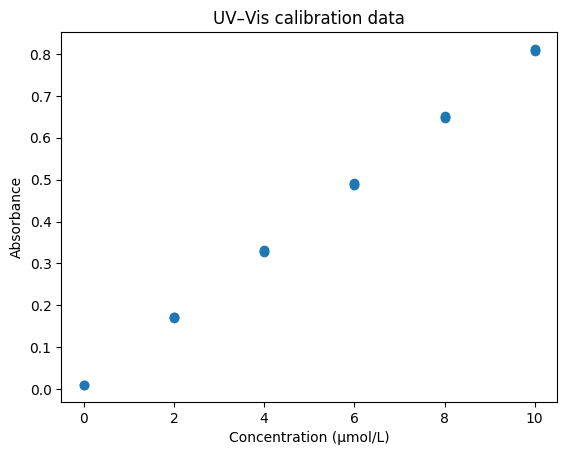

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data/uvvis_calibration.csv")
standards = data[data["sample_type"].isin(["blank", "standard"])]

plt.scatter(standards["concentration_uM"], standards["absorbance"])
plt.xlabel("Concentration (µmol/L)")
plt.ylabel("Absorbance")
plt.title("UV–Vis calibration data")
plt.show()


Punktene ser ut til å følge en omtrent rett linje. Det gir oss en kjemisk og visuell grunn til å prøve en lineær modell.

### Lineær regresjon

```{admonition} Lineær regresjon
Lineær regresjon er en metode for å tilpasse en rett linje til datapunkter. Linja velges slik at den samlet ligger så nær målepunktene som mulig.
```

Vi bruker `linregress` fra SciPy til å finne den rette linja som passer best til punktene:



In [4]:
import numpy as np
from scipy import stats

concentrations = standards["concentration_uM"]
absorbances = standards["absorbance"]

result = stats.linregress(concentrations, absorbances)
slope = result.slope
intercept = result.intercept
r_squared = result.rvalue**2

print(f"Slope: {slope:.5f} L/µmol")
print(f"Intercept: {intercept:.5f}")
print(f"R²: {r_squared:.6f}")

Slope: 0.07989 L/µmol
Intercept: 0.01037
R²: 0.999964


Resultatet fra `linregress` inneholder blant annet stigningstall, konstantledd og korrelasjonskoeffisient. Vi kvadrerer korrelasjonskoeffisienten for å få $R^2$. Disse tre tallene må tolkes kjemisk.

#### Stigningstallet

Stigningstallet forteller hvor mye absorbansen ifølge modellen øker når konsentrasjonen øker med 1 µmol/L. Et brattere stigningstall betyr at signalet endres mer for en gitt konsentrasjonsendring. I denne sammenhengen sier vi at metoden har større følsomhet.

Stigningstallet er ikke det samme som presisjon. To metoder kan ha samme stigningstall, men ulik spredning mellom replikatene.

#### Konstantleddet

Konstantleddet er absorbansen modellen forventer når konsentrasjonen er null. Det kan blant annet påvirkes av blankbidrag og instrumentets nullpunkt.

Beer–Lamberts lov kan skrives uten konstantledd, men vi bør ikke automatisk tvinge regresjonslinja gjennom origo. Det krever at vi har en god faglig grunn til å anta at signalet virkelig er null ved konsentrasjon null.

#### $R^2$

```{admonition} Forklaringsgraden $R^2$
$R^2$ er et tall mellom 0 og 1 som beskriver hvor godt variasjonen i målepunktene følger den lineære modellen. En verdi nær 1 betyr at punktene ligger nær en rett linje.
```

$R^2$ beskriver hvor mye av variasjonen i absorbansen som den rette linja fanger opp i dette datasettet. En verdi nær 1 passer med at punktene ligger nær en rett linje.

Et høyt $R^2$ er likevel ikke et kvalitetsstempel alene. Vi må også se på punktene, kontrollere at den ukjente prøven ligger i kalibreringsområdet og vurdere om modellen er kjemisk rimelig. En modell kan få høyt $R^2$ selv om enkelte målinger er dårlige eller det høyeste konsentrasjonsområdet begynner å avvike fra Beer–Lamberts lov.

### Vis data og modell sammen



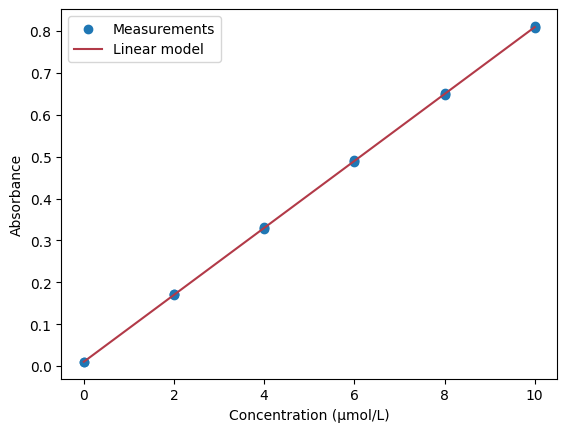

In [5]:
x_model = np.linspace(standards["concentration_uM"].min(), standards["concentration_uM"].max(), 100)
y_model = slope * x_model + intercept

plt.scatter(standards["concentration_uM"], standards["absorbance"], label="Measurements")
plt.plot(x_model, y_model, color="#b23a48", label="Linear model")
plt.xlabel("Concentration (µmol/L)")
plt.ylabel("Absorbance")
plt.legend()
plt.show()


Vi beholder råmålingene i figuren. Dersom vi bare viser ett gjennomsnitt for hver konsentrasjon, skjuler vi variasjonen mellom replikatene.

### Bestem den ukjente konsentrasjonen

For en ukjent prøve måler vi absorbansen og løser likningen med hensyn på konsentrasjonen:

$$
c=\frac{A-b}{a}
$$



In [6]:
unknown = data[data["sample_type"] == "unknown"]
unknown_mean_absorbance = unknown["absorbance"].mean()

unknown_concentration = unknown_mean_absorbance-intercept/ slope

print(f"Mean unknown absorbance: {unknown_mean_absorbance:.3f}")
print(f"Estimated concentration: {unknown_concentration:.2f} µmol/L")


Mean unknown absorbance: 0.604
Estimated concentration: 0.47 µmol/L


Dette er et punktestimat. Det betyr at vi får ett beste anslag, men ikke at konsentrasjonen er kjent uten usikkerhet. Replikatene til den ukjente prøven varierer, og selve kalibreringslinja er også bestemt fra målinger med variasjon.

Vi skal ikke beregne hele usikkerheten i den ukjente konsentrasjonen her. Det viktigste på dette nivået er å være klar over at svaret ikke blir nøyaktig bare fordi Python skriver ut mange desimaler.

Du kan utforske kalibreringen i editoren nedenfor.

<iframe src="../../basthon/?from=examples/calibration_regression.py" width="100%" height="690" frameborder="0" title="Interactive Python editor for UV-Vis calibration" loading="lazy" allowfullscreen></iframe>

````{admonition} Underveisoppgave
:class: tip

1. Legg til 0,01 i alle absorbansverdiene. Hva skjer med stigningstallet og konstantleddet?
2. Endre bare den høyeste kalibreringsstandarden. Hva skjer med linja og $R^2$?
3. Prøv en ukjent absorbans som er høyere enn alle standardene. Hvorfor bør vi være forsiktige med svaret?

```{admonition} Løsningsforslag
:class: tip, dropdown
Når alle absorbansene økes like mye, endres først og fremst konstantleddet. En endring i ett kalibreringspunkt kan påvirke både stigningstall og $R^2$. En ukjent absorbans utenfor området krever ekstrapolasjon: Vi antar da at den lineære sammenhengen fortsetter i et område vi ikke har undersøkt.
```
````

## Del 2: Sammenlikne et resultat med en referanseverdi

Tenk deg at vi analyserer et sertifisert referansemateriale. Den sertifiserte konsentrasjonen er 5,00 mg/L, og vi får disse resultatene:



In [7]:
measurements_mg_L = np.array([5.12, 5.08, 5.15, 5.10, 5.13])
reference_value = 5.00

Gjennomsnittet er 5,116 mg/L. Forskjellen fra 5,00 mg/L kan skyldes tilfeldig målevariasjon, men den kan også tyde på at metoden gir systematisk for høye resultater.

### Start med konfidensintervallet

I forrige kapittel beregnet vi et 95 % konfidensintervall fra omtrent 5,082 til 5,150 mg/L. Referanseverdien 5,00 mg/L ligger utenfor intervallet. Det forteller oss at 5,00 mg/L er vanskelig å forene med måleserien dersom antakelsene bak intervallet er rimelige.

Konfidensintervallet er ofte et godt sted å starte fordi det viser både estimatet og usikkerheten. Vi kan også formulere spørsmålet som en hypotesetest.

## Hypotesetest uten mystikk

En hypotesetest begynner med en påstand vi undersøker.

```{admonition} Nullhypotese
Nullhypotesen, $H_0$, er påstanden testen tar utgangspunkt i. I eksempelet er nullhypotesen at middelverdien til måleprosessen er 5,00 mg/L.
```

Testen spør: *Hvor uvanlig ville måleresultatet vårt vært dersom denne nullhypotesen var riktig?*

Svaret oppsummeres i en p-verdi.

```{admonition} p-verdi
p-verdien er sannsynligheten for å få det observerte resultatet, eller et enda større avvik, dersom nullhypotesen og forutsetningene for testen er riktige. En liten p-verdi betyr at resultatet er vanskelig å forene med nullhypotesen.
```

Vi velger ofte et signifikansnivå på 0,05:

- Dersom $p<0{,}05$, sier vi at dataene gir grunnlag for å forkaste nullhypotesen.
- Dersom $p\geq0{,}05$, sier vi at dataene ikke gir tilstrekkelig grunnlag for å forkaste den.

En p-verdi er ikke sannsynligheten for at nullhypotesen er sann. En høy p-verdi beviser heller ikke at to verdier er like. Den kan også skyldes at vi har få eller upresise målinger.

### Ettutvalgs t-test

Når vi sammenlikner gjennomsnittet fra én måleserie med én kjent eller sertifisert verdi, kan vi bruke en ettutvalgs t-test:



In [ ]:
from scipy import stats

test = stats.ttest_1samp(measurements_mg_L, popmean=reference_value)

print(f"t statistic: {test.statistic:.3f}")
print(f"p value: {test.pvalue:.5f}")

t statistic: 9.600
p value: 0.00066


Her blir p-verdien mindre enn 0,05. Dataene gir dermed grunnlag for å si at middelverdien avviker fra den sertifiserte verdien. Vi bør likevel også vurdere størrelsen på avviket. En statistisk tydelig forskjell er ikke nødvendigvis stor nok til å ha kjemisk eller praktisk betydning.

Testen bygger på de samme hovedantakelsene som det t-baserte konfidensintervallet: Målingene skal være uavhengige, og målefordelingen bør være omtrent normal.

## Del 3: Sammenlikne to analysemetoder

To metoder brukes på de samme åtte prøvene. Hver rad inneholder derfor et par resultater: ett fra metode A og ett fra metode B.



In [ ]:
methods = pd.read_csv("data/method_comparison.csv")

methods["difference_mg_L"] = (
    methods["method_B_mg_L"] - methods["method_A_mg_L"]
)

print(methods[["sample_id", "difference_mg_L"]])


Det er forskjellen innen hvert par som er viktig. En prøve med høy konsentrasjon vil vanligvis gi et høyt resultat med begge metodene. Ved å trekke resultatene fra hverandre undersøker vi om den ene metoden gjennomgående gir høyere eller lavere verdier enn den andre.

### Paret t-test

```{admonition} Paret t-test
En paret t-test brukes når de samme prøvene er målt på to måter. Testen undersøker om gjennomsnittet av forskjellene innen hvert prøvepar er forskjellig fra null.
```



In [ ]:
test = stats.ttest_rel(methods["method_B_mg_L"], methods["method_A_mg_L"])

mean_difference = methods["difference_mg_L"].mean()

print(f"Mean paired difference: {mean_difference:.3f} mg/L")
print(f"p value: {test.pvalue:.5f}")


Dersom p-verdien er liten, har vi evidens for en systematisk forskjell mellom metodene. Middelforskjellen forteller hvor stor forskjellen er og hvilken metode som gir de høyeste resultatene.

Vi bør rapportere begge deler. P-verdien alene forteller ikke om forskjellen på for eksempel 0,20 mg/L er viktig for formålet analysen skal brukes til.

Du kan utforske metodesammenlikningen i editoren nedenfor.

<iframe src="../../basthon/?from=examples/inference_method_comparison.py" width="100%" height="520" frameborder="0" title="Interactive Python editor for a paired method comparison" loading="lazy" allowfullscreen></iframe>

```{admonition} Hvorfor ikke behandle resultatene som to uavhengige grupper?
De samme prøvene er målt med begge metodene. Resultatene hører derfor sammen parvis. En test som ignorerer parene, svarer på et annet spørsmål og kaster bort informasjon om forskjellen innen hver prøve.
```

## Hva bruker vi når?

| Kjemisk spørsmål | Metode | Eksempel |
|---|---|---|
| Hvordan henger signal og konsentrasjon sammen? | Lineær regresjon | Kalibreringskurve i UV–Vis |
| Hvor usikkert er gjennomsnittet fra en måleserie? | 95 % konfidensintervall | Rapportere middelverdien for et referansemateriale |
| Avviker én måleserie fra en kjent verdi? | Ettutvalgs t-test | Måler vi samme verdi som den sertifiserte konsentrasjonen? |
| Gir to metoder ulike resultater for de samme prøvene? | Paret t-test | Samme vannprøver analyseres med to metoder |
| Er én på forhånd mistenkelig verdi uvanlig stor eller liten? | Faglig kontroll, eventuelt Grubbs' test | Én replikat skiller seg tydelig fra de andre |

Legg merke til at testen velges ut fra forsøksdesignet og spørsmålet, ikke ut fra hvilken test som gir ønsket p-verdi.

## Del 4: En mistenkelig måling

En verdi som skiller seg tydelig fra resten, kan skyldes feil innskriving, forurensning, feil prøvepreparering, instrumentfeil eller en reell kjemisk forskjell. Før vi beregner en test, bør vi derfor:

1. se på rådataene
2. kontrollere enheter, instrumentlogg og laboratorienotater
3. undersøke om prøven ble behandlet annerledes
4. dokumentere hva vi finner

Vi skal aldri fjerne en verdi bare fordi standardavviket blir mindre eller kalibreringslinja ser penere ut uten den.

### Grubbs' test

```{admonition} Grubbs' test
Grubbs' test undersøker om den mest ekstreme observasjonen i en omtrent normalfordelt måleserie er uvanlig langt fra resten. Testen er laget for én på forhånd mistenkelig verdi.
```

Grubbs' test kan brukes når **én verdi er mistenkelig**, og målingene ellers kan antas å komme fra en omtrent normalfordelt populasjon. Testen sammenlikner avstanden fra den mest ekstreme verdien til gjennomsnittet med standardavviket i hele måleserien:

$$
G=\frac{\text{største avstand fra gjennomsnittet}}{s}
$$



In [ ]:
measurements_mg_L = np.array([10.02, 10.05, 9.98, 10.01, 10.42])
alpha = 0.05

n = len(measurements_mg_L)
mean = np.mean(measurements_mg_L)
sample_sd = np.std(measurements_mg_L, ddof=1)
deviations = np.abs(measurements_mg_L - mean)

suspect_index = np.argmax(deviations)
G_calculated = deviations[suspect_index] / sample_sd

t_critical = stats.t.ppf(1 - alpha / (2 * n), df=n - 2)
G_critical = (n - 1) / np.sqrt(n) * np.sqrt(
    t_critical**2 / (n - 2 + t_critical**2)
)

print(f"G calculated: {G_calculated:.3f}")
print(f"G critical: {G_critical:.3f}")


Dersom den beregnede verdien er større enn den kritiske verdien, flagger testen den mest ekstreme målingen. Det er et signal om at verdien er vanskelig å forene med resten av måleserien under antakelsene til testen.

Det er ikke en automatisk sletteknapp. Testen kan ikke fortelle om avviket skyldes feilpipettering eller en reell forskjell i prøven. Den er også laget for én mulig utligger og bør ikke gjentas til datasettet ser pent ut.

Du kan undersøke testen i editoren nedenfor.

<iframe src="../../basthon/?from=examples/calibration_grubbs.py" width="100%" height="560" frameborder="0" title="Interactive Python editor for Grubbs' test" loading="lazy" allowfullscreen></iframe>

````{admonition} Underveisoppgave
:class: tip
Beregn gjennomsnitt og standardavvik med og uten 10,42 mg/L. Kjør deretter testen. Hvilken informasjon trenger du i tillegg til testresultatet før du eventuelt utelater målingen?

```{admonition} Løsningsforslag
:class: tip, dropdown
Den høye verdien øker både gjennomsnittet og standardavviket. Før den eventuelt utelates, trenger vi informasjon om blant annet prøvepreparering, instrumentlogg og om prøven kan være kjemisk forskjellig. Beslutningen og konsekvensen for resultatet bør dokumenteres.
```
````

## En enkel arbeidsflyt

Når vi skal bruke statistikk i et kjemisk arbeid, kan vi følge denne rekkefølgen:

1. Formuler det kjemiske spørsmålet.
2. Finn ut hva hver observasjon representerer, og om målinger hører sammen parvis.
3. Se på rådataene og lag en relevant figur.
4. Velg statistisk størrelse eller test ut fra spørsmålet.
5. Kontroller at forutsetningene er rimelige.
6. Rapporter både tallresultatet og hva det betyr kjemisk.

Python kan utføre beregningen, men valget og tolkningen må fortsatt bygge på forsøket.

## Kort oppsummering

- Lineær regresjon kan knytte et målt signal til konsentrasjon i et undersøkt kalibreringsområde.
- Stigningstall, konstantledd og $R^2$ må tolkes sammen med dataene og den kjemiske modellen.
- Et konfidensintervall viser estimat og usikkerhet. En p-verdi sier hvor uvanlige dataene er under en nullhypotese.
- Ettutvalgs t-test brukes mot én referanseverdi. Paret t-test brukes når de samme prøvene er målt med to metoder.
- En statistisk forskjell er ikke automatisk kjemisk viktig.
- En mistenkelig verdi må undersøkes faglig. Grubbs' test kan støtte vurderingen, men ikke erstatte den.

## Oppgaver

```{admonition} Oppgave 4.1 – forstå kalibreringslinja
:class: tip
Bruk `uvvis_calibration.csv` til å utføre en lineær regresjon. Rapporter stigningstall, konstantledd og $R^2$. Forklar med ord hva stigningstallet og konstantleddet betyr i denne UV–Vis-analysen.
```

```{admonition} Oppgave 4.2 – bestem en ukjent
:class: tip
Beregn middelabsorbansen til den ukjente prøven og bestem konsentrasjonen med kalibreringsmodellen. Kontroller at signalet ligger innenfor området til standardene. Hvorfor bør du ikke rapportere alle desimalene Python gir?
```

```{admonition} Oppgave 4.3 – hva kan $R^2$ fortelle?
:class: tip
En student skriver: «$R^2=0{,}999$, derfor er konsentrasjonen til den ukjente prøven helt riktig.» Forklar minst tre problemer med denne konklusjonen.
```

```{admonition} Oppgave 4.4 – referanseverdi
:class: tip
Målingene `[99.8, 100.3, 100.1, 99.9, 100.4]` mg/L skal sammenliknes med en sertifisert verdi på 100,0 mg/L. Beregn først et 95 % konfidensintervall. Utfør deretter en ettutvalgs t-test. Skriv en konklusjon med vanlig språk.
```

```{admonition} Oppgave 4.5 – velg riktig metode
:class: tip
Velg mellom lineær regresjon, ettutvalgs t-test, paret t-test og Grubbs' test. Begrunn valget.

1. En ny metode brukes på ti prøver som også er analysert med referansemetoden.
2. Seks målinger av et sertifisert materiale sammenliknes med sertifikatverdien.
3. Fluorescens måles for fem kjente konsentrasjoner.
4. Én av fem replikater er mistenkelig høy etter en dokumentert pipetteringshendelse.
```

```{admonition} Oppgave 4.6 – to analysemetoder
:class: tip
Bruk `method_comparison.csv`. Beregn forskjellen mellom metode B og metode A for hver prøve. Finn middelforskjellen og utfør en paret t-test. Gir metode B gjennomgående høyere eller lavere resultater? Er størrelsen på forskjellen viktig for bruksområdet?
```

```{admonition} Oppgave 4.7 – mistenkelig måling
:class: tip
Bruk måleserien `[10.02, 10.05, 9.98, 10.01, 10.42]` mg/L. Utfør Grubbs' test, og skriv deretter en kort beslutningslogg med: observert problem, statistisk resultat, mulig kjemisk forklaring og hvilken mer informasjon du trenger.
```

```{admonition} Oppgave 4.8 – samlet UV–Vis-case
:class: tip
Bruk `uvvis_calibration.csv` til å lage et kalibreringsplott, utføre lineær regresjon og bestemme konsentrasjonen til den ukjente prøven. Skriv en kort rapport som inneholder modell, enheter, konsentrasjonsestimat og to begrensninger ved resultatet.
```

## Video

I videoen nedenfor kan du få en innføring eller repetisjon i regresjonsanalyse.

<iframe width="800" height="600" src="https://www.youtube.com/embed/GrLWboUtL3A?autoplay=0&rel=0" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
